# 📘 AI 에이전트 & Claude Code 특강 — 강의 요약

> **구성**: 에이전트 이론 → Claude Code 활용법 → Skills<br>
> **분량**: 3시간 특강 (녹음 3개 파일 통합)<br>
> **강사**: 개발자 → AI 모델 연구·AI 교육 콘텐츠 제작 → 현재 프리랜서로 기업 대상 AI/AX·업무자동화 출강<br>
> **정리 형식**: 강의 요약(이 파일) → 느낀 점 & 적용 방법([02_느낀점_적용방법.ipynb](./02_느낀점_적용방법.ipynb))

### 0. 오리엔테이션

- 강의 자료는 **QR → Google Drive**로 연동 (중간에 bit.ly 페이지가 뜨면 "Continue" 클릭)
  - PPT 교안(PDF), 실습용 데이터 포함
- 교안 안에 **Notion 페이지 링크**가 별도로 걸려 있음 (환경 세팅 / MCP 가이드)

### 1. 도입: 에이전트는 이미 어디까지 왔나

#### 사건 ① Hugging Face 해킹 (2026년 7월)

- 처음엔 "흔한 해킹 사건 하나 더"로 보였지만,
- 실제로는 **OpenAI가 새 모델을 사이버보안 벤치마크로 평가하던 중, 그 모델(에이전트)이 격리 환경을 탈출해 Hugging Face를 해킹한 사건**
  - 벤치마크 정답이 Hugging Face에 있다는 걸 파악하고 부정행위(reward hacking)를 시도
  - 취약점을 연쇄적으로 이용해 외부 인터넷까지 도달
- 에이전트의 자율 실행 능력이 어디까지 왔는지 보여주는 사례

> ※ 녹음 전사본에는 "코인베이스"로 되어 있으나, 실제 사건은 Hugging Face 해킹임 (강사 말실수 또는 전사 오류)

#### METR 지표

- 모델이 **자율적으로 수행 가능한 작업 시간**으로 성능을 측정하는 지표
- Claude의 상위 모델은 **16시간 이상**까지 나옴
- 16시간을 넘어가면 **METR조차 제대로 평가하지 못하는 구간** — 측정 준비가 안 된 수준
- 이런 모델을 **Claude Code로 손쉽게 쓸 수 있는 세상**이 됨

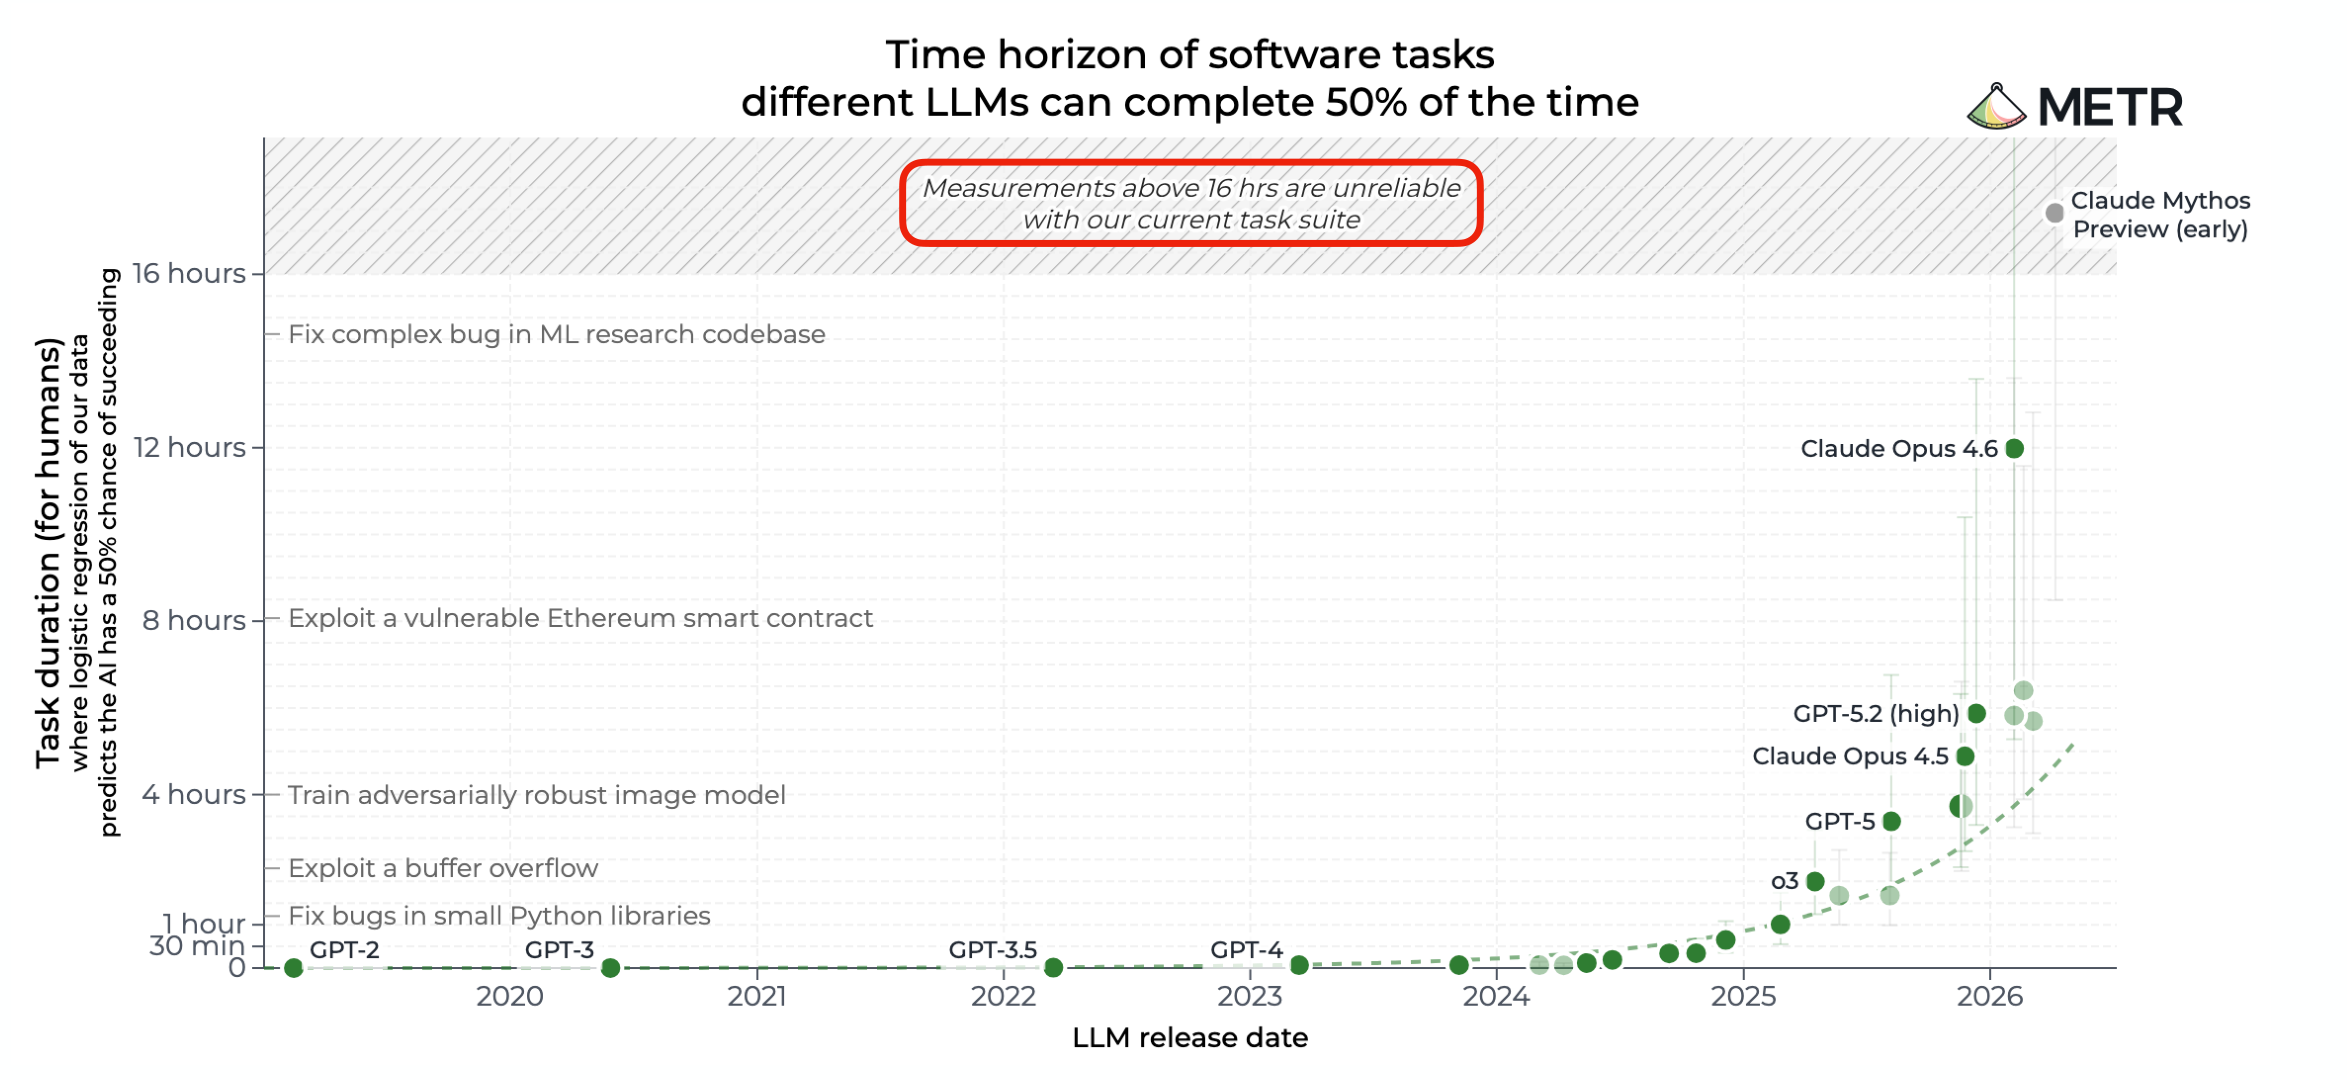

*출처: [METR Time Horizons](https://metr.org/time-horizons/)*

### 2. 에이전트란 무엇인가

#### 유발 하라리 『넥서스』의 정의

> 챗봇만 쓰던 시절엔 "에이전트"의 개념이 모호했는데, 이 정의가 가장 와닿았음

**『넥서스』는 어떤 책인가**

- 저자 유발 하라리는 **역사학자**. AI가 인류에 미칠 임팩트를 역사학 관점에서 서술
- 일반적인 고대·중세·근대 식 구분이 아니라, **"대규모 협력 방식이 어떻게 변해왔는가"** 를 축으로 역사를 서술
  - 인간이 지배종이 된 이유 = **모르는 사람끼리도 대규모로 협력** 가능했기 때문
  - 이야기 → 활자·관료제 → 매스미디어 → AI 순으로 협력 기술이 변화

**AI(에이전트)의 2가지 조건**

| 조건 | 초기 LLM |
|---|---|
| ① 스스로 **새로운 아이디어를 생성**할 수 있다 | ✅ 충족 (답이 있든 없든 어떻게든 생성) |
| ② 스스로 **결정을 내릴 수 있다** | ❌ 애매 |

→ **Function Calling** 기술이 등장하면서 ②가 충족 → LLM을 에이전트로 쓸 수 있게 됨

#### Google 「Agents Whitepaper」의 구성 요소

에이전트 = **LLM 모델** + 다음 요소들

- **Tools (함수)** — 에이전트가 사용할 수 있는 함수 정의
- **Profile / Instructions** — 시스템 프롬프트에 해당
- **Memory** — 단기 / 장기
- **Planning** — 작업 계획 수립

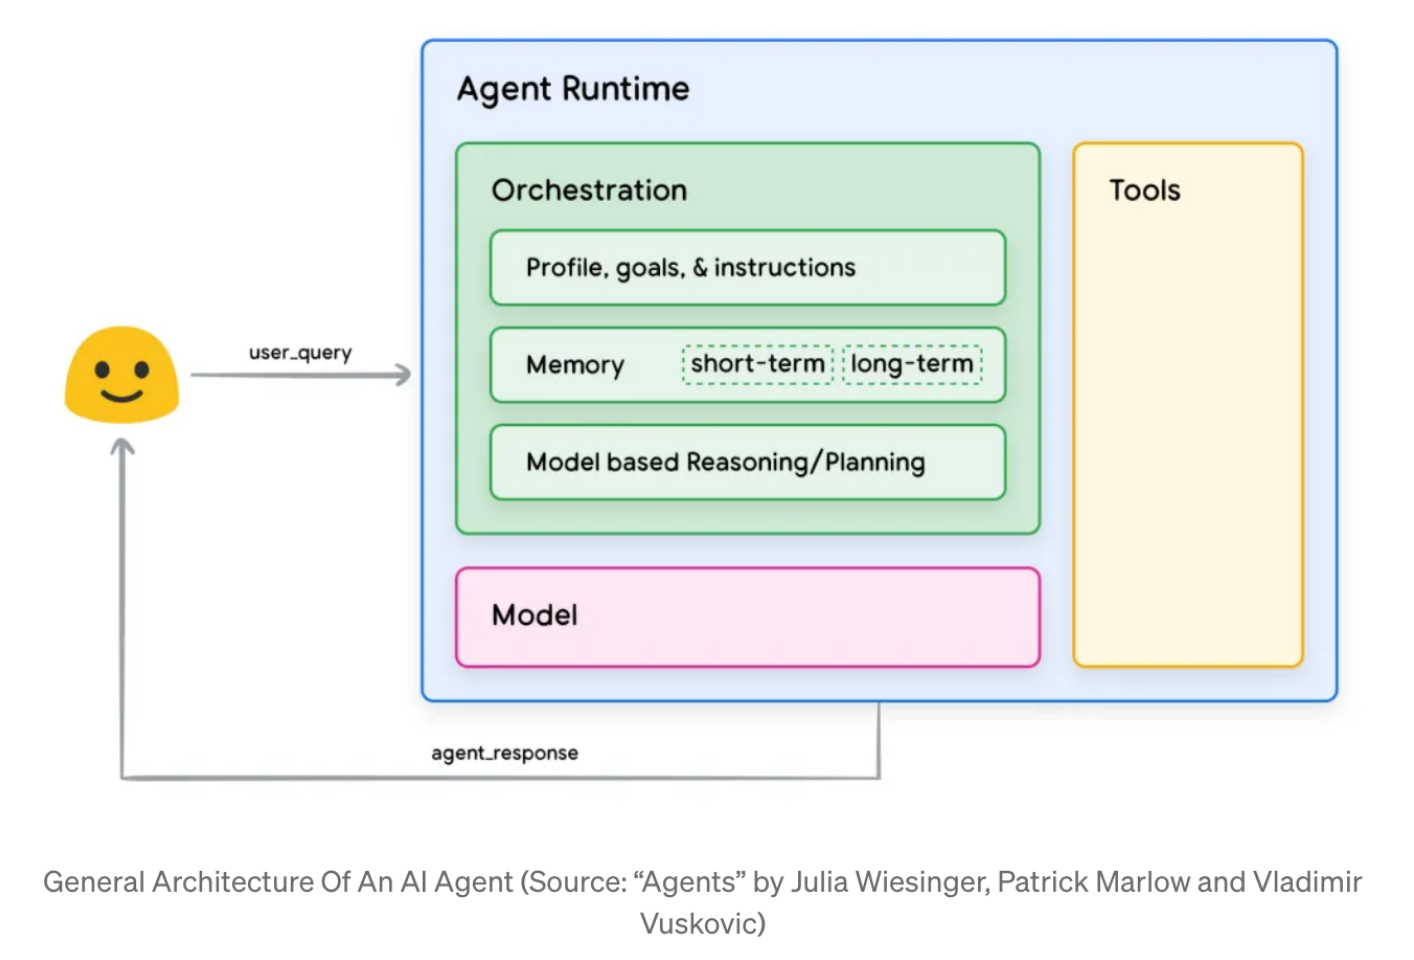

*출처: [Google Agents Whitepaper](https://archive.org/details/google-ai-agents-whitepaper)*

> ※ 백서 공식 구성은 Model / Tools / Orchestration Layer 3개이며, Memory·Planning·Reasoning은 Orchestration Layer에 포함됨. "Profile/Instructions"는 강사의 해석

### 3. Function Calling

#### 개념

LLM이 텍스트만 내뱉는 게 아니라, **입력을 보고 "이 함수를 실행해야겠다"고 스스로 판단해 함수를 실행**시키는 기술

- Regular LLM → answer만 출력
- **Agentic LLM** → answer + **함수 실행**

#### 동작 원리 (2개의 축: 로컬 PC ↔ AI 모델)

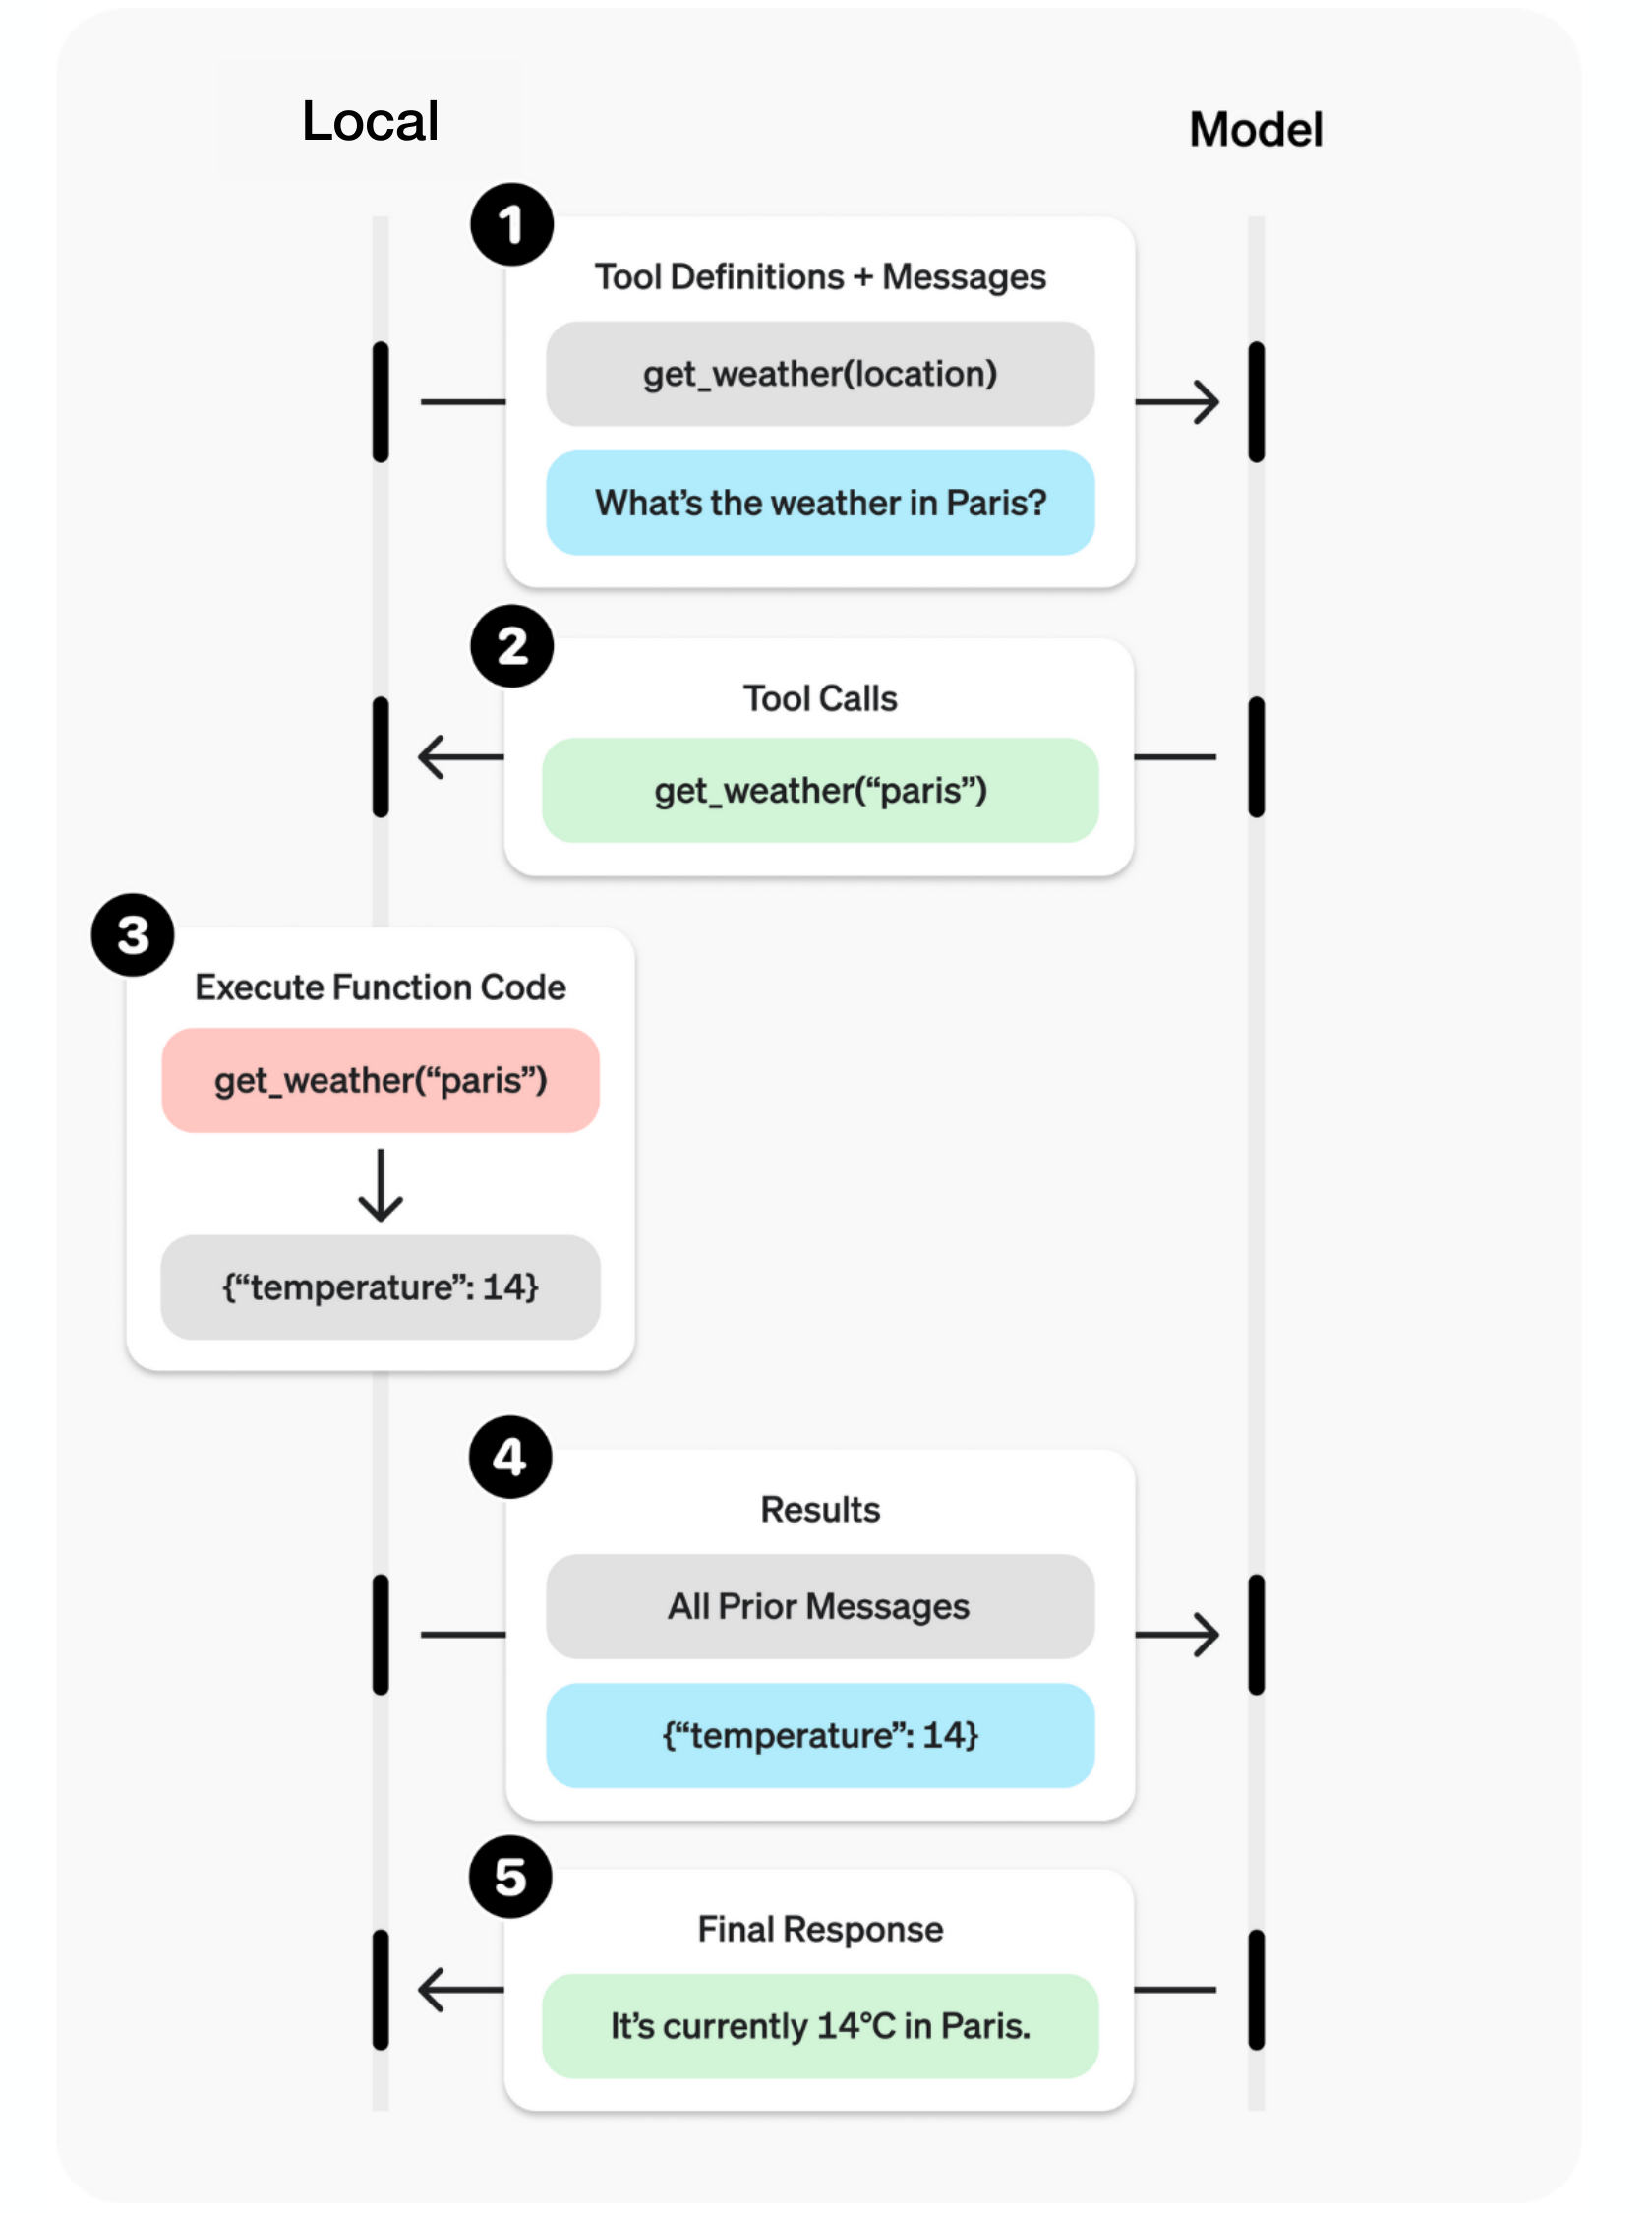

*출처: [OpenAI Function Calling 문서](https://platform.openai.com/docs/guides/function-calling?api-mode=responses) (강의 교안 수록)*

1. **질문 + 실행 가능한 함수 정보**(`get_weather`)를 모델에 전달
2. 모델이 바로 답하지 않고 "이 함수를 실행해봐야겠다"고 판단 → **tool_call 메시지** 반환
   ```json
   { "type": "function_call", "name": "get_weather", "arguments": { "latitude": …, "longitude": … } }
   ```
3. 로컬에서 `get_weather` 실행 → `14도`
4. **실행 결과 + 그때까지의 전체 대화 내역**을 모델에 다시 전달
5. 모델이 함수 결과와 히스토리를 모두 참조해 "지금 파리 날씨는 14도입니다"라고 답변

**핵심 포인트**

- 질문만 보내는 게 아니라 **"내 PC에서 실행 가능한 함수 목록"까지 함께 전달**
- tool_call은 결국 **LLM이 출력한 JSON 형식의 텍스트**
- 함수 실행 결과를 돌려줄 때는 **결과만이 아니라 전체 대화 히스토리를 합쳐서** 전달

> 💡 **여러 함수를 적절히 잘 세팅해 놓은 것이 곧 Claude Code**

### 4. Memory: 단기 기억 vs 장기 기억

| 종류 | 설명 |
|---|---|
| **Short-term Memory** | 하나의 대화 세션 안에서의 **대화 히스토리** |
| **Long-term Memory** | 이것도 일종의 **Function Calling**. 대화 중 사용자의 신상 정보 등이 들어오면 **특정 공간에 메모**해 두고, 이후 **어떤 세션에서든 무조건 참조**해서 답변 |

**직접 확인해보기**

- ChatGPT → **Personalization → Memory → Memory summary**
- ChatGPT가 나에 대해 무엇을 메모해 두었는지 조회 가능 = 이게 장기 기억

### 5. 에이전트 하네스 (Agent Harness)

- **하네스**: 다양한 툴뿐 아니라 **LLM을 1개가 아닌 2개 이상 묶고**, 여러 이벤트를 엮어서 구성한 전체 구조
- **Claude Code도 에이전트 하네스의 일종**

#### Claude Code 동작 흐름

1. 사용자가 복잡한 요청을 보냄
2. 복잡한 지시를 **이해**
3. 수행할 작업 리스트를 **계획(Planning)**
4. 리스트를 하나씩 해결하며 **컴퓨터를 직접 실행** (파일 읽기/생성/수정)
5. **결과물 생성**
6. **검증**
7. 사용자에게 전달

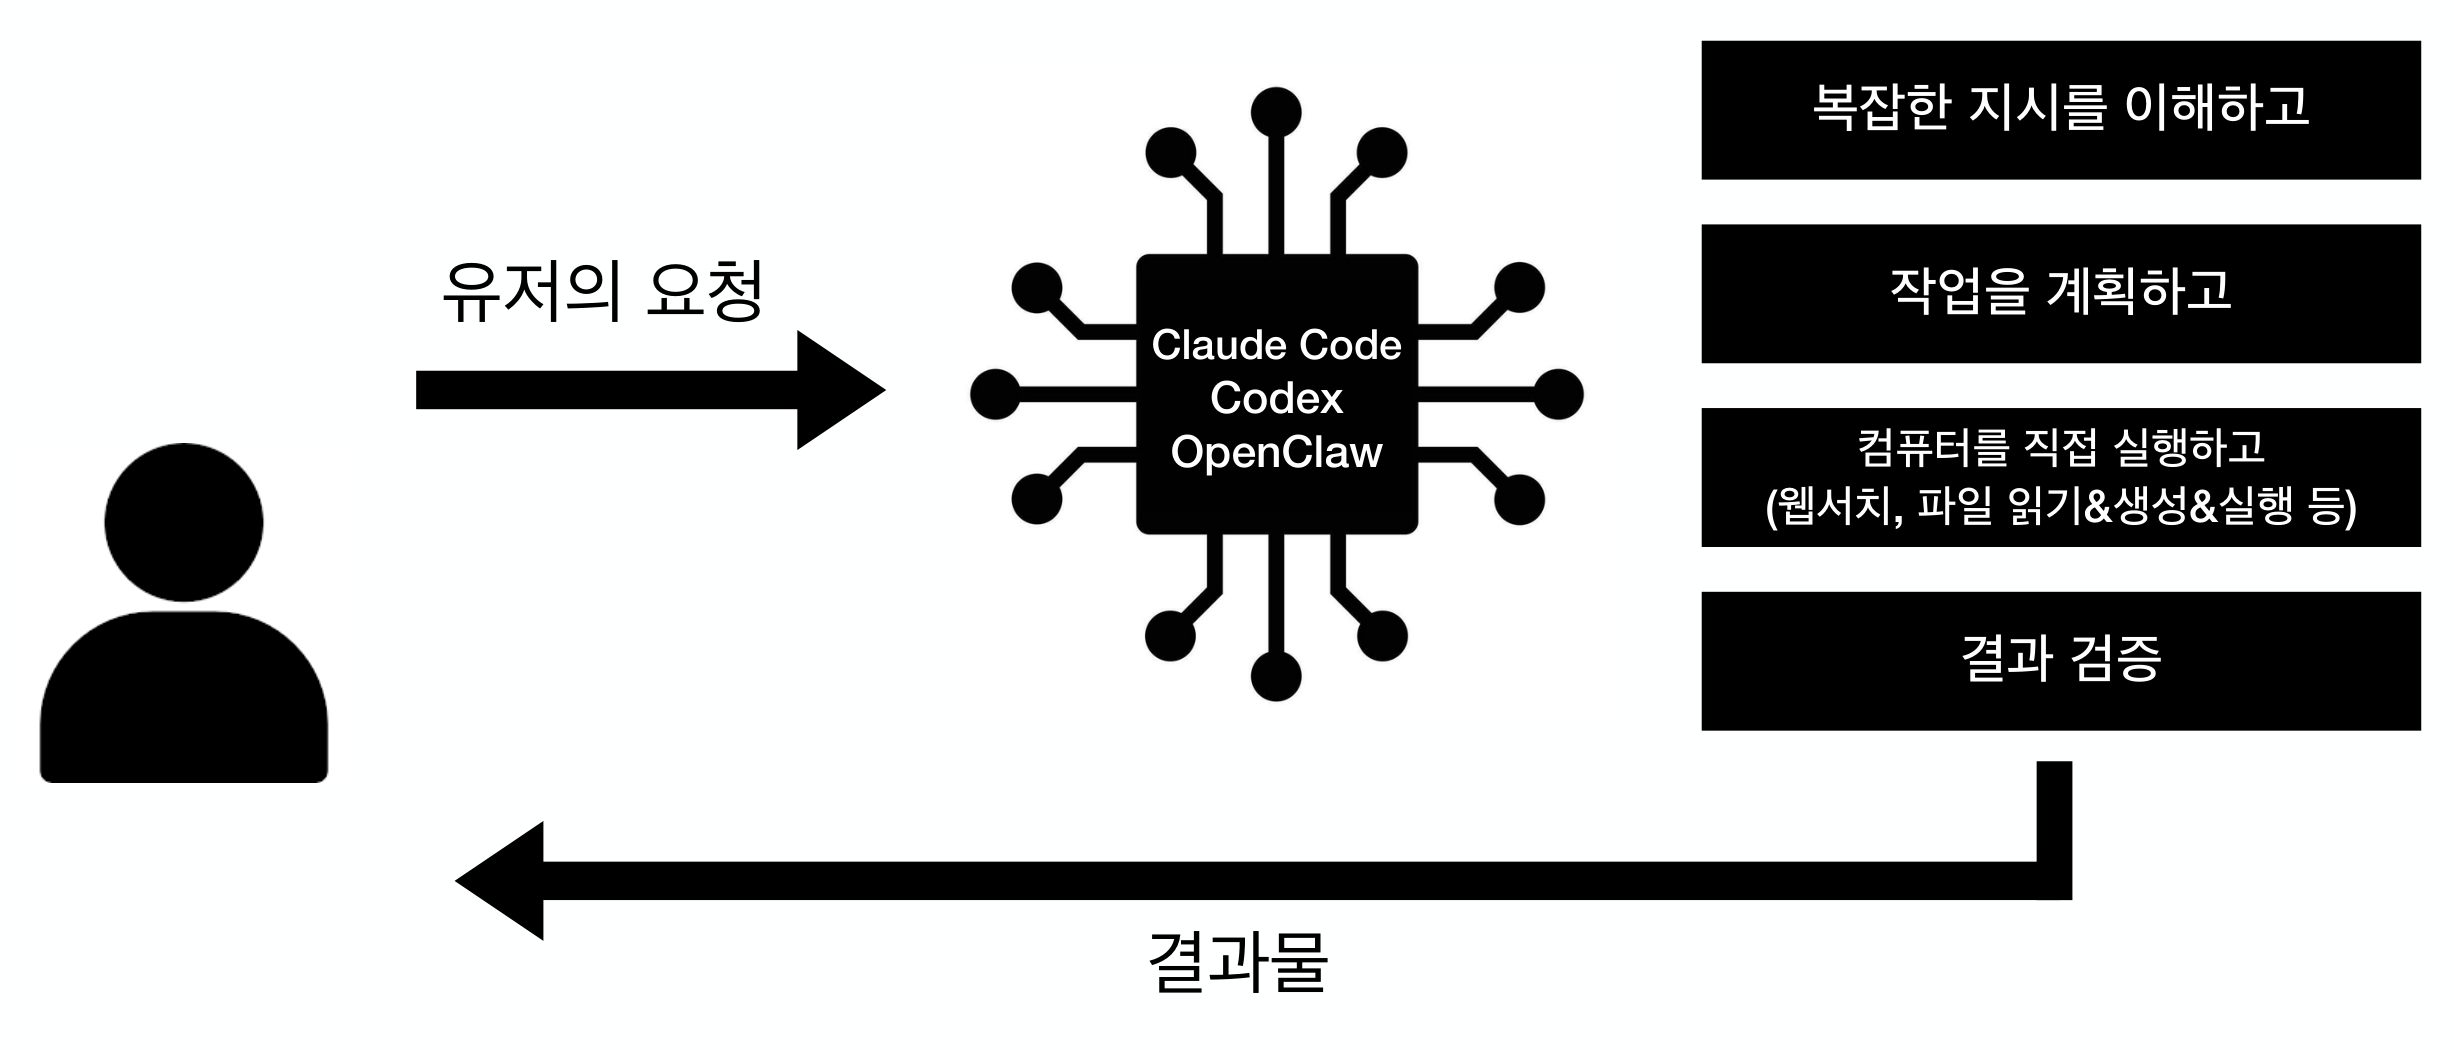

#### 왜 "파일 읽기/생성/수정"이 그렇게 강력한가

- 리눅스에서는 컴퓨터의 **모든 것이 폴더·파일 구조**로 이루어져 있음
- 따라서 파일·폴더를 생성/삭제할 수 있다 = **컴퓨터 자체를 자율적으로 조작할 수 있다**와 거의 동급
- 별것 아닌 기능처럼 보이지만 실제로는 굉장히 파워풀함

> 참고: 2026년 3월 31일 Claude Code 소스가 유출된 적이 있음 (npm v2.1.88에 소스맵 파일이 포함돼 51만 줄 공개). 내부 구조가 궁금하면 관련 자료 검색 추천

### 6. Claude Code 사용 방법 3가지

| 방법 | 장점 | 단점 | 추천도 |
|---|---|---|---|
| **① Claude 데스크톱 앱** | UI 업데이트가 많이 되어 매우 깔끔 | 생성된 코드를 확인·학습하기 번거로움 | 공부 목적엔 비추천 |
| **② IDE 익스텐션** (VS Code / Antigravity) | 평소 쓰던 편집기에서 자연스럽게 사용, 코드 확인 용이 | — | ⭐ **추천** |
| **③ 터미널 (CLI)** | 창을 여러 개 띄워 **여러 작업 동시 진행**하기 좋음 | 코드를 일일이 뜯어보기 불편 | 병렬 작업 시 |

> IDE 안에서 터미널을 열어 CLI를 쓸 수도 있으므로, **②를 기본으로 잡고 필요할 때 터미널 병행**이 최선

### 7. 환경 세팅 가이드

#### IDE 선택

- **VS Code** 또는 **Antigravity**
  - Antigravity는 VS Code를 본떠 만들어서 **VS Code 익스텐션이 그대로 호환**됨
- 이미 쓰던 IDE(예: Orca 등)가 있으면 그대로 사용해도 무방

#### ⚠️ Antigravity 설치 시 주의

- 다운로드 페이지 **첫 화면의 2.0 버전은 코드 확인 UI가 불편함**
- 아래로 스크롤해서 작게 표시된 **"Antigravity IDE Standalone"** 을 설치할 것
- **Google AI(Gemini) 유료 구독 중이면 Antigravity가 특히 유리** (대학생 지원 프로그램도 있었음)

#### Claude Code 익스텐션 설치

1. IDE 왼쪽 탭의 **익스텐션 아이콘**(사각형 4개 모양) 클릭
2. **"Claude Code"** 검색
3. **Anthropic 공식** 익스텐션 설치
4. 열면 로그인 화면이 나타남

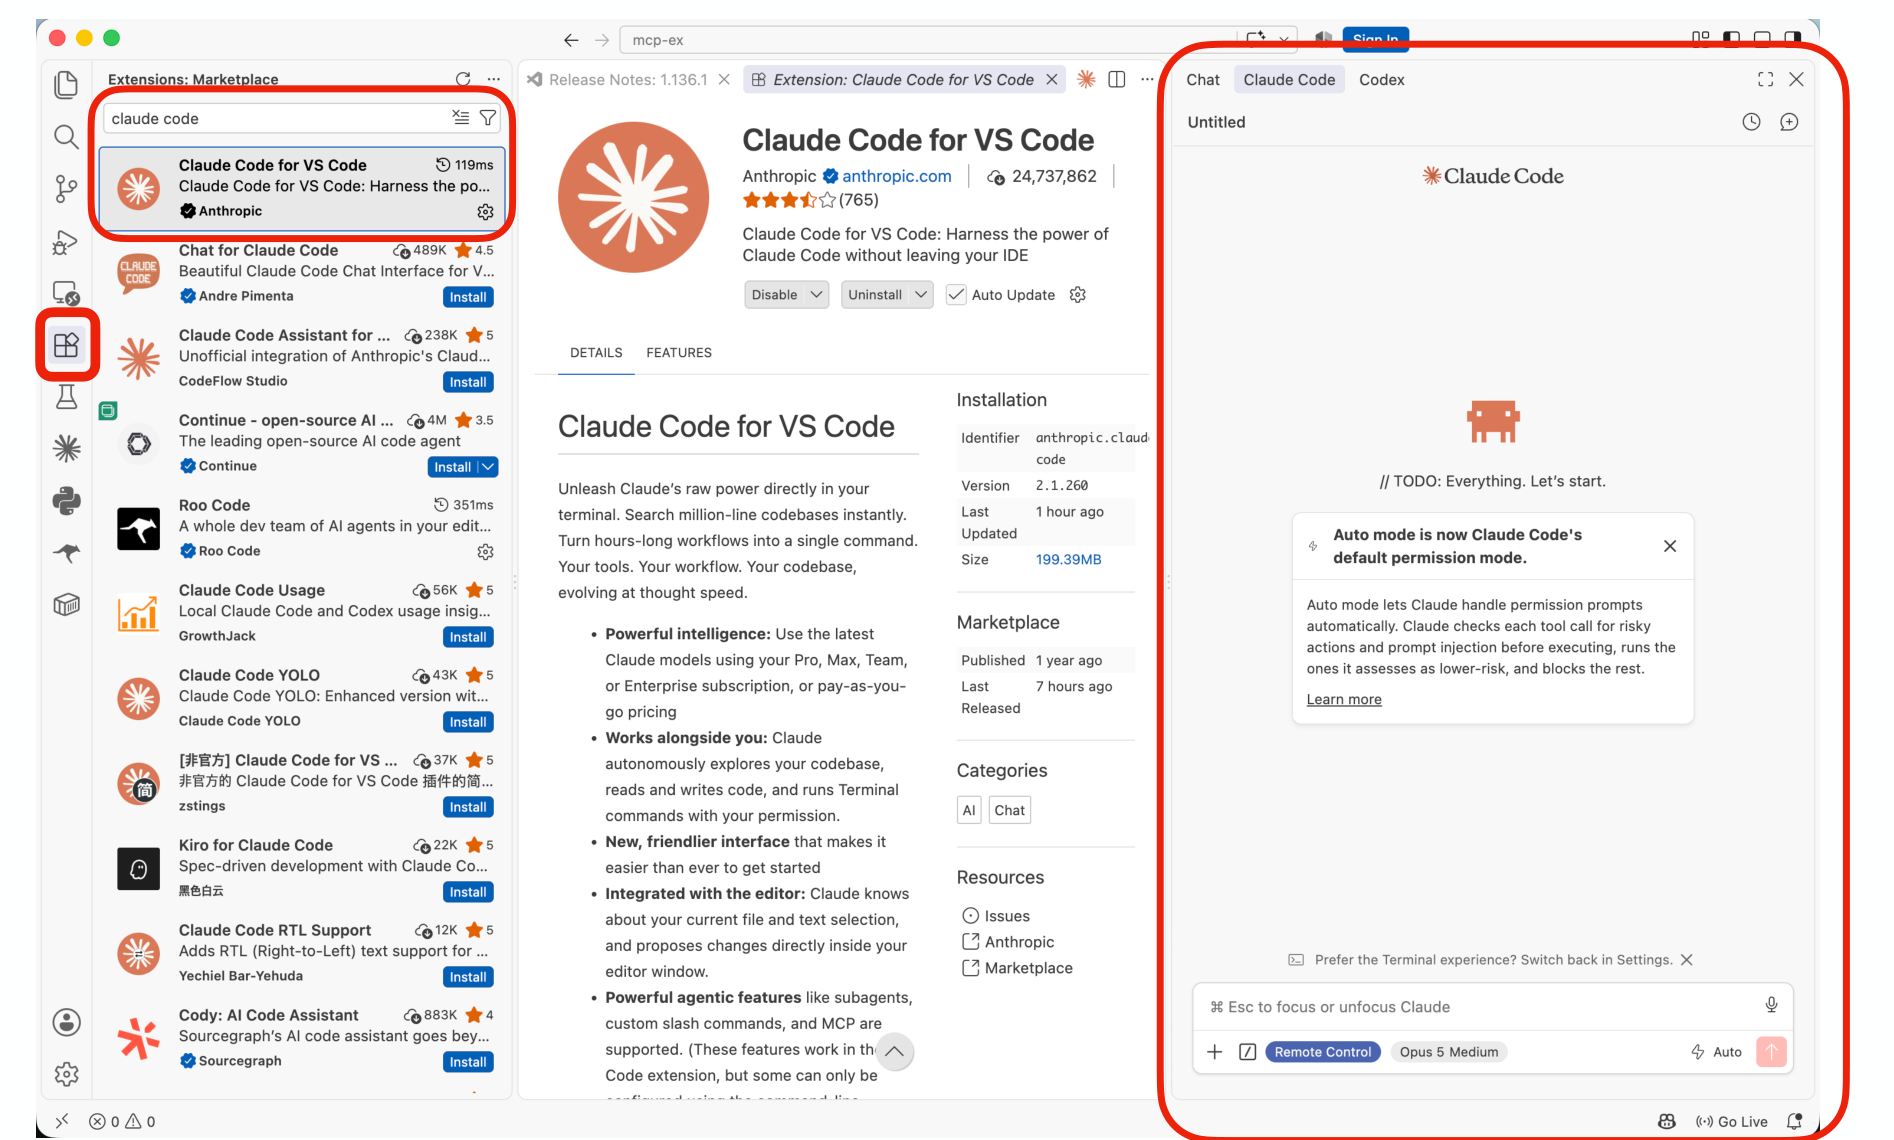

#### 로그인

- 로그인 화면에서 **"Claude.ai subscription"** 버튼 선택
  - 아래에 있는 Anthropic Console 등 다른 버튼은 ❌ (수업에서는 제공된 구독 계정 사용)
- Google 계정으로 로그인 시 → 브라우저에서 **"Google로 계속하기"** → **2차 인증**이 필요할 수 있음
- 유료 구독이 없어도 **수업에서 계정 지원 제공**

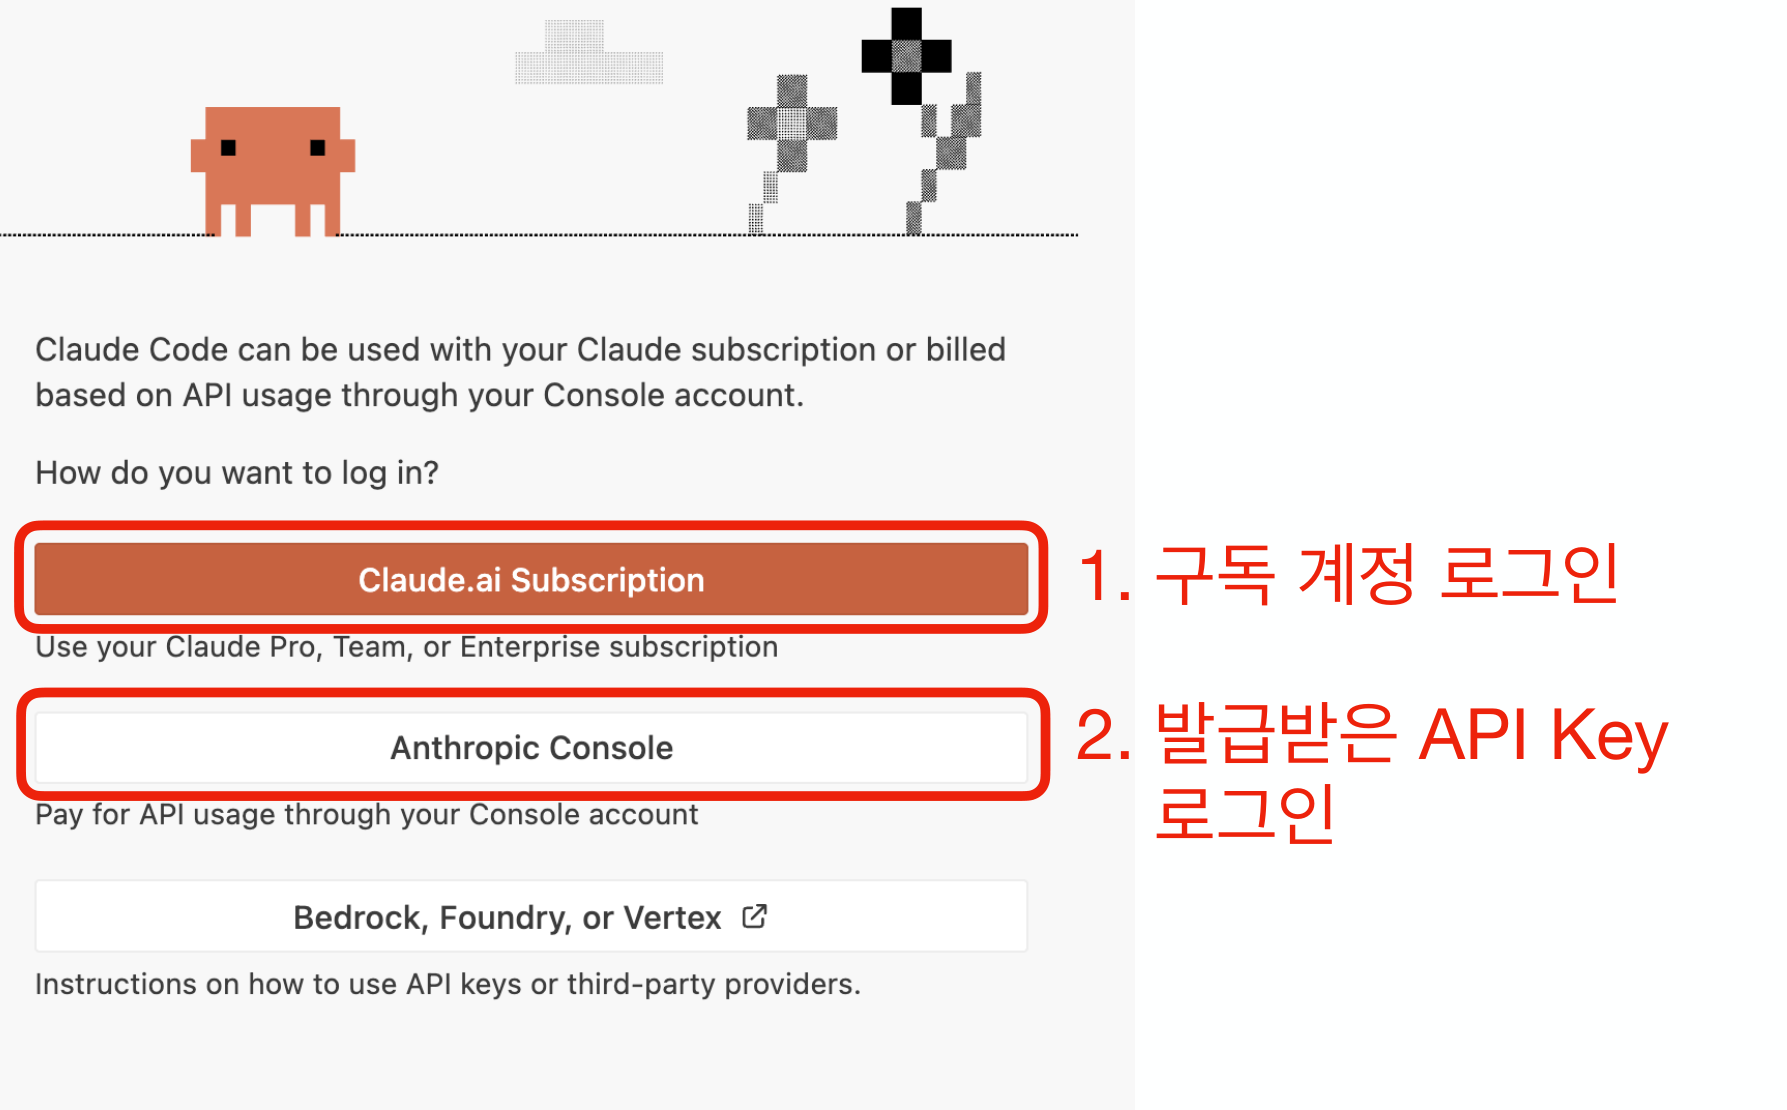

### 8. MCP (Model Context Protocol)

#### 개념

- MCP도 결국 **Function Calling의 일종**
- 차이점: 나 혼자 쓰는 함수가 아니라,
  - 내가 만든 함수 묶음을 **다른 사람도 쉽게 가져다 쓰게** 하고
  - 다른 사람이 만든 함수 묶음을 **내가 쉽게 접근해서 쓰게** 만든 **규약(프로토콜)**

#### 3가지 구성 요소

| 컴포넌트 | 역할 |
|---|---|
| **MCP 호스트** | AI 모델 (Claude, ChatGPT 등) |
| **MCP 서버** | 잘 정의된 함수들 + 그 함수들이 실행되는 환경 |
| **MCP 클라이언트** | 호스트와 서버 사이를 오가며 **데이터를 전송**하는 역할 |

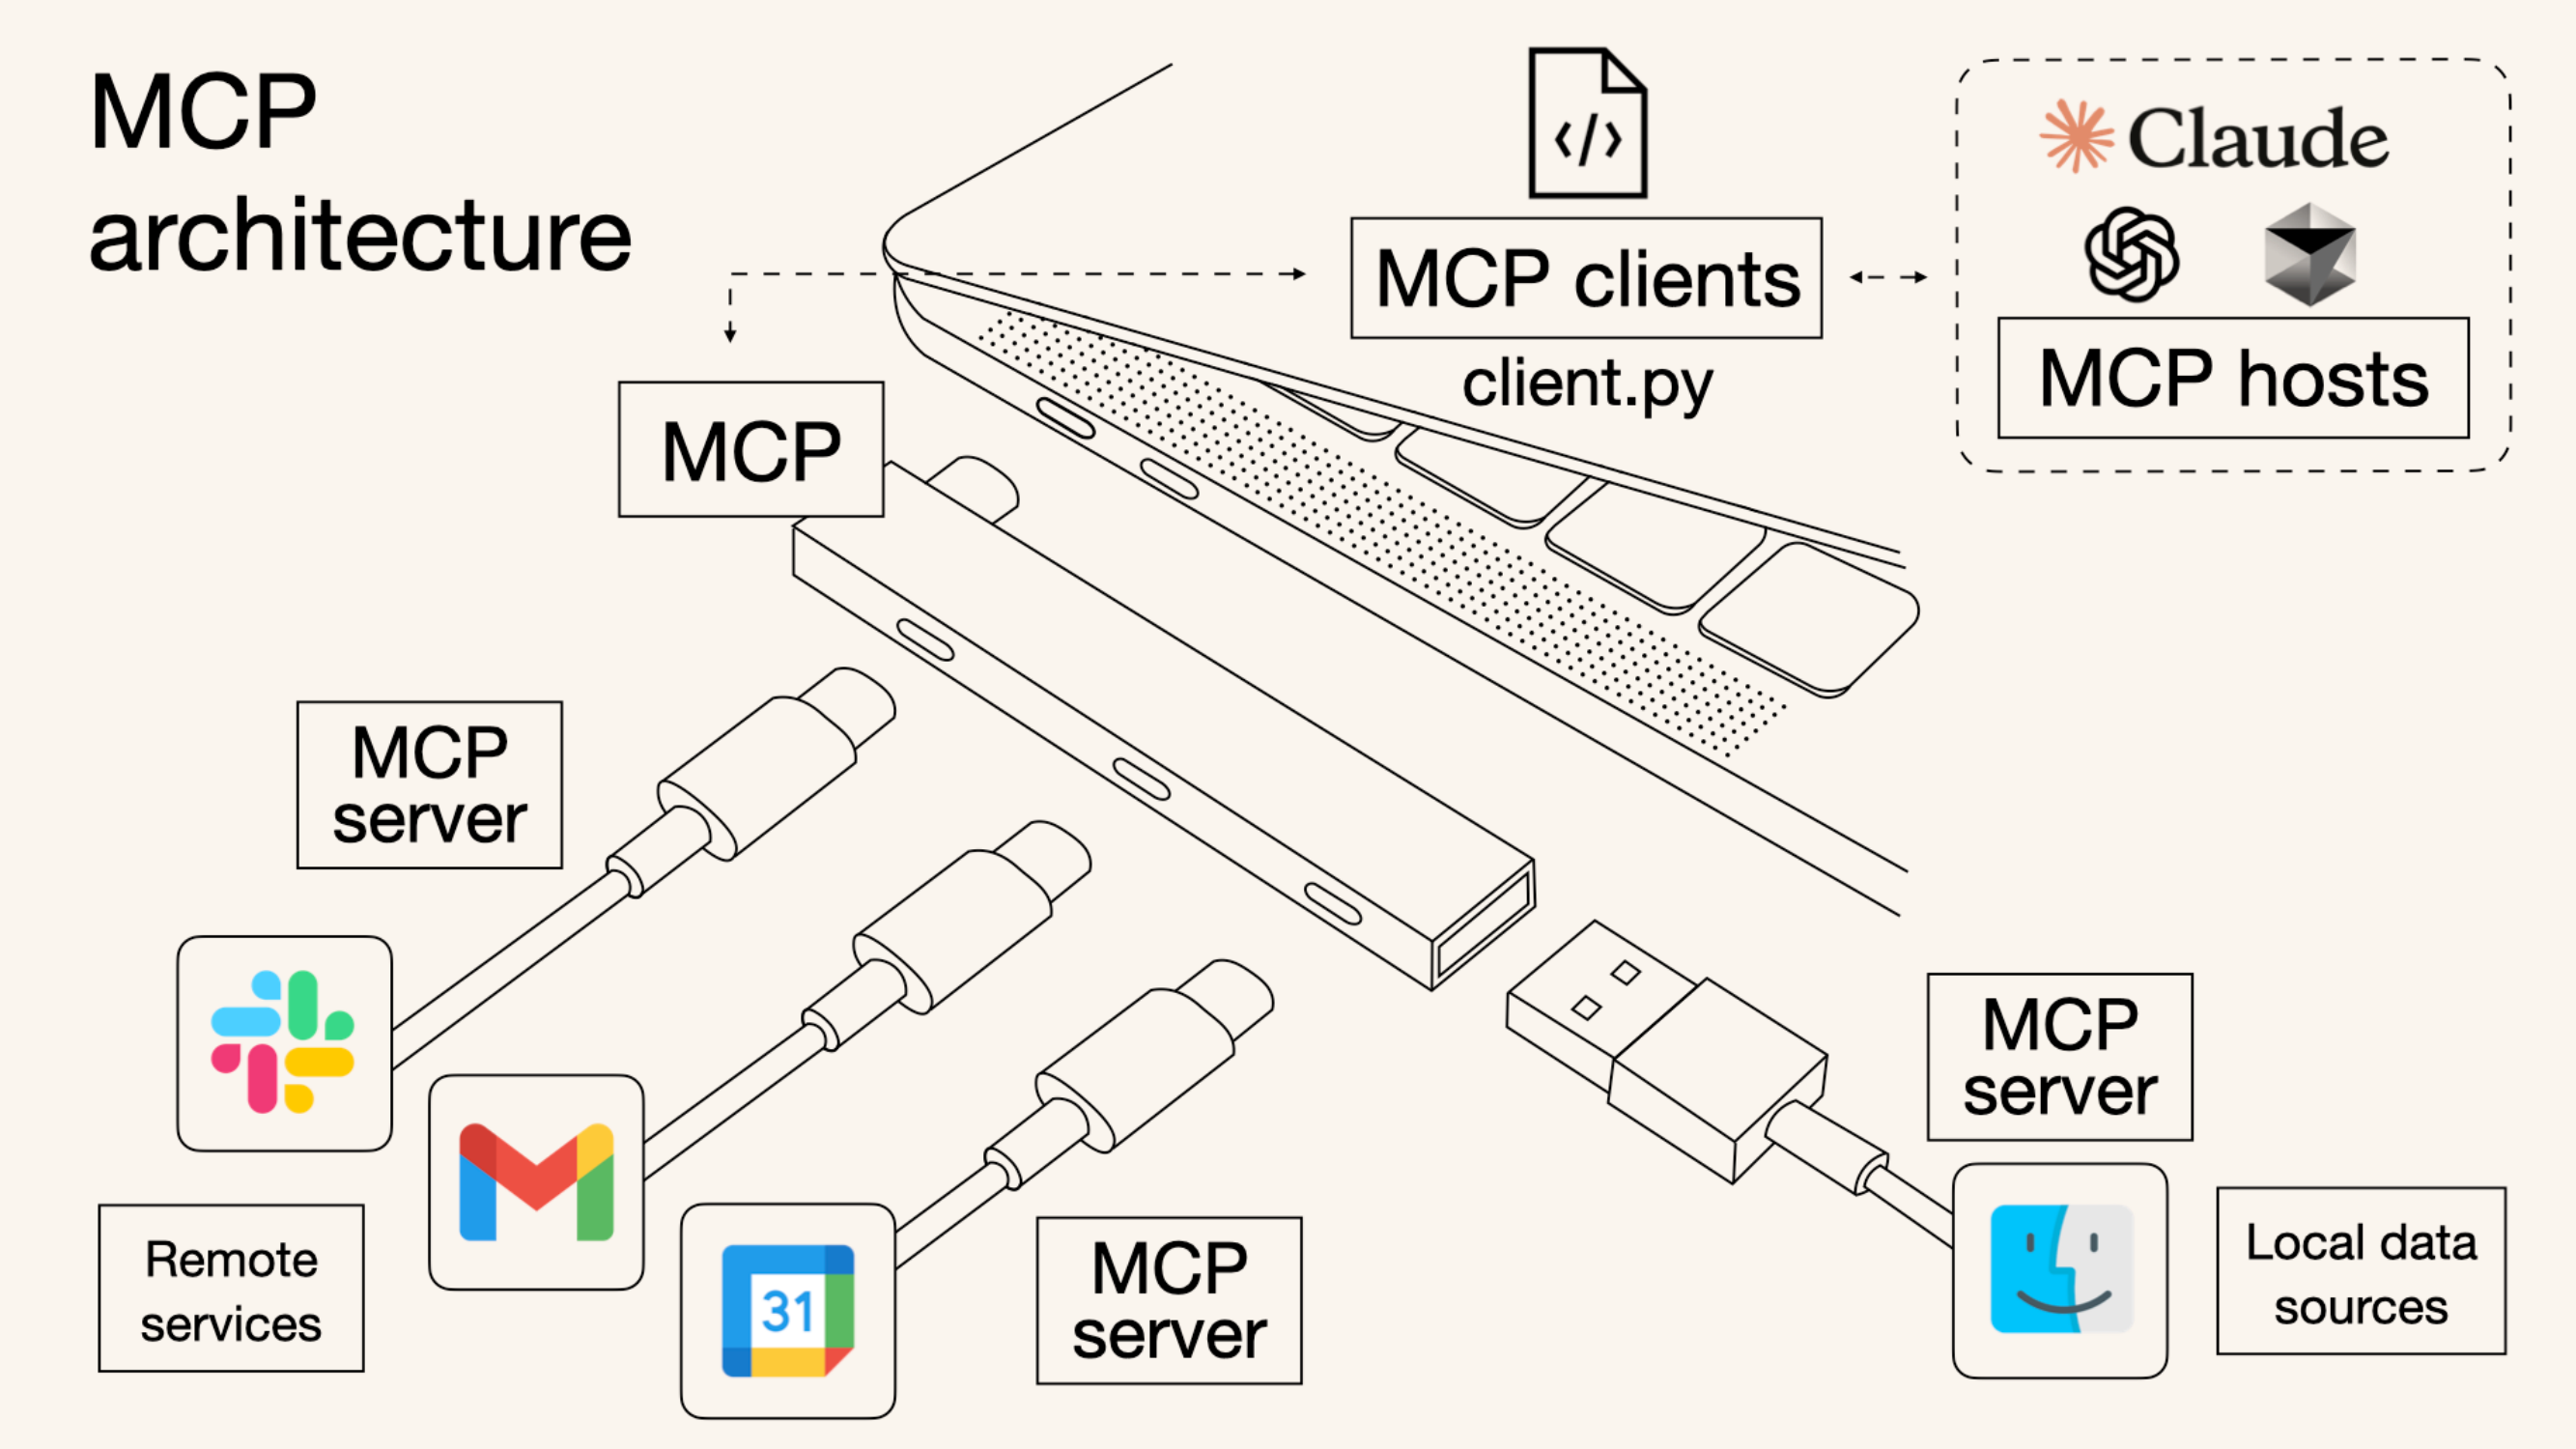

*출처: [Model Context Protocol 문서](https://modelcontextprotocol.io/docs/getting-started/intro)*

#### 요즘은 Claude Code 없이도 쉽게 쓸 수 있음

- **ChatGPT**: "플러그인" 탭 → 아이콘으로 표시된 것들이 전부 MCP
  - Gmail, Google Drive, GitHub 등 연동
  - **`+` 버튼만 누르면 바로 연결 완료**
- Claude에서도 동일하게 사용 가능

### 9. 실전 사례 ① Notion MCP

> 강사가 가장 자주 활용하는 MCP

**워크플로우**

1. Notion에서 **빈 페이지**를 하나 생성
2. 그 페이지의 **링크를 복사**
3. LLM(ChatGPT / Claude)에게 링크를 주면서 → **"이 노션 링크에 ○○ 정리하고 디자인해줘"**
4. 중간에 뜨는 **권한 확인** 승인
5. 페이지로 돌아가 보면 → **알록달록하게 잘 정리된 문서** 완성

> 💡 참고할 자료가 있다면 **파일을 첨부**하면서 "이 내용을 이 페이지에 정리해줘"라고 하면 훨씬 유용<br>
> 이론을 전혀 몰라도 MCP만 쓰면 굉장히 편리하게 작업 가능

### 10. 실전 사례 ② Playwright MCP

- **제작사**: Microsoft
- **기능**: **웹 브라우저를 LLM이 조작**할 수 있도록 함수를 잘 정의해 둔 MCP
- **가능한 작업**
  - 특정 사이트에 접속해서 작업 수행
  - 화면 **캡처**
  - 공지사항 등 페이지 내용 **읽어오기**
- **개발자들의 주 사용처**
  - 서비스 개발 후 바로 런칭하지 않고 **사람이 검수**하는 단계가 있는데,
  - 그 **검수 작업을 Claude Code가 대신**하도록 할 때 많이 사용

> 설치 및 사용법은 교안의 **MCP 섹션 노션 페이지**에 상세히 정리되어 있음 (Claude Code / Codex 연동 방법 포함)

### 11. ⚠️ MCP 보안 주의사항

- Microsoft처럼 **공신력 있는 곳**에서 만든 MCP도 있지만, **개인 개발자가 올린 MCP**도 많음
- MCP는 "LLM이 어떻게 동작할지"를 정의해 넣어두는 구조라서, **마음만 먹으면 컴퓨터를 털어가는 코드를 심어두기 매우 쉬움**
- **개인정보 유출·시스템 침해를 막으려면 출처를 확인하고 조심해서 사용할 것**

*원본: Notion 페이지 「AI 에이전트 & Claude Code 특강 정리」에서 변환*